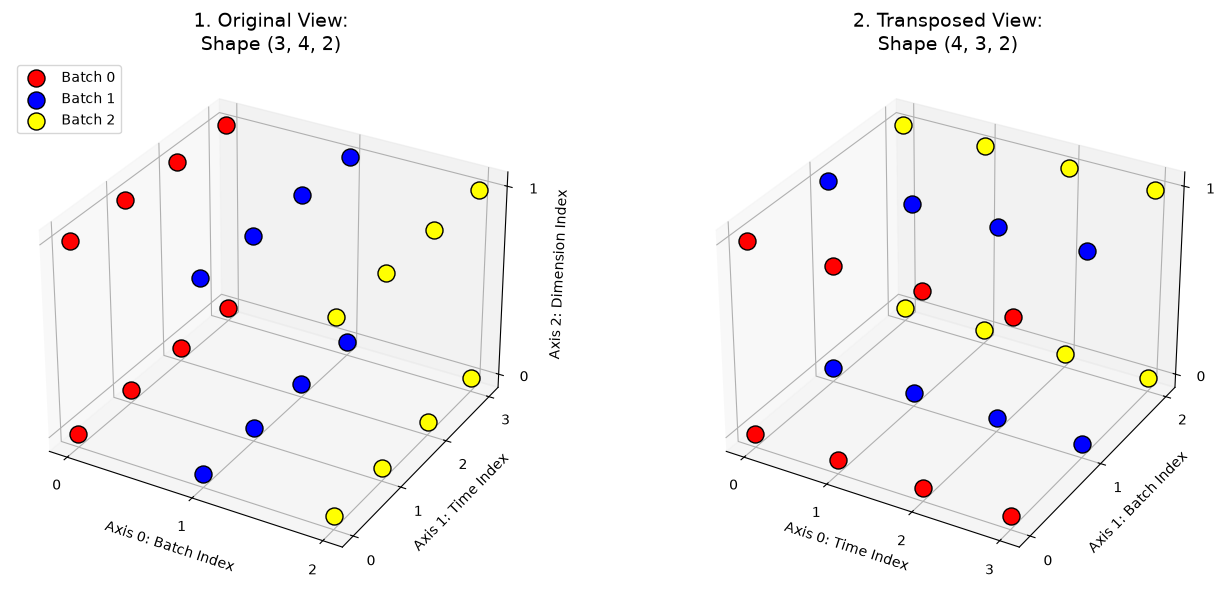

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Setup Data Structure ---
num_batches = 3
num_time_steps = 4
num_dimensions = 2

fig = plt.figure(figsize=(14, 6))
batch_colors = ['red', 'blue', 'yellow']

# =========================================================================
# === Visualization 1: Original (Batch, Time, Dimensions) ===
# =========================================================================
ax1 = fig.add_subplot(121, projection='3d')

# We plot the INDICES to show the physical shape of the array
# Axis 0 (X) = Batch, Axis 1 (Y) = Time, Axis 2 (Z) = Dimensions
for b in range(num_batches):
    for t in range(num_time_steps):
        for d in range(num_dimensions):
            ax1.scatter(b, t, d, color=batch_colors[b], s=150, edgecolors='black', 
                        label=f'Batch {b}' if (t==0 and d==0) else "")

ax1.set_title("1. Original View:\nShape (3, 4, 2)", fontsize=14)
ax1.set_xlabel("Axis 0: Batch Index")
ax1.set_ylabel("Axis 1: Time Index")
ax1.set_zlabel("Axis 2: Dimension Index")

# Force integer ticks for indices
ax1.set_xticks(range(num_batches))
ax1.set_yticks(range(num_time_steps))
ax1.set_zticks(range(num_dimensions))
ax1.legend(loc='upper left')

# =========================================================================
# === Visualization 2: Transposed (Time, Batch, Dimensions) ===
# =========================================================================
ax2 = fig.add_subplot(122, projection='3d')

# After np.transpose(data, (1, 0, 2)), the shape is (4, 3, 2).
# Axis 0 (X) is now Time, Axis 1 (Y) is now Batch.
for b in range(num_batches):
    for t in range(num_time_steps):
        for d in range(num_dimensions):
            # Notice the physical coordinates swapped: X is 't', Y is 'b'
            ax2.scatter(t, b, d, color=batch_colors[b], s=150, edgecolors='black')

ax2.set_title("2. Transposed View:\nShape (4, 3, 2)", fontsize=14)
ax2.set_xlabel("Axis 0: Time Index")
ax2.set_ylabel("Axis 1: Batch Index")
ax2.set_zlabel("Axis 2: Dimension Index")

# Ticks are updated to match the new shape
ax2.set_xticks(range(num_time_steps))
ax2.set_yticks(range(num_batches))
ax2.set_zticks(range(num_dimensions))

plt.tight_layout()
plt.show()

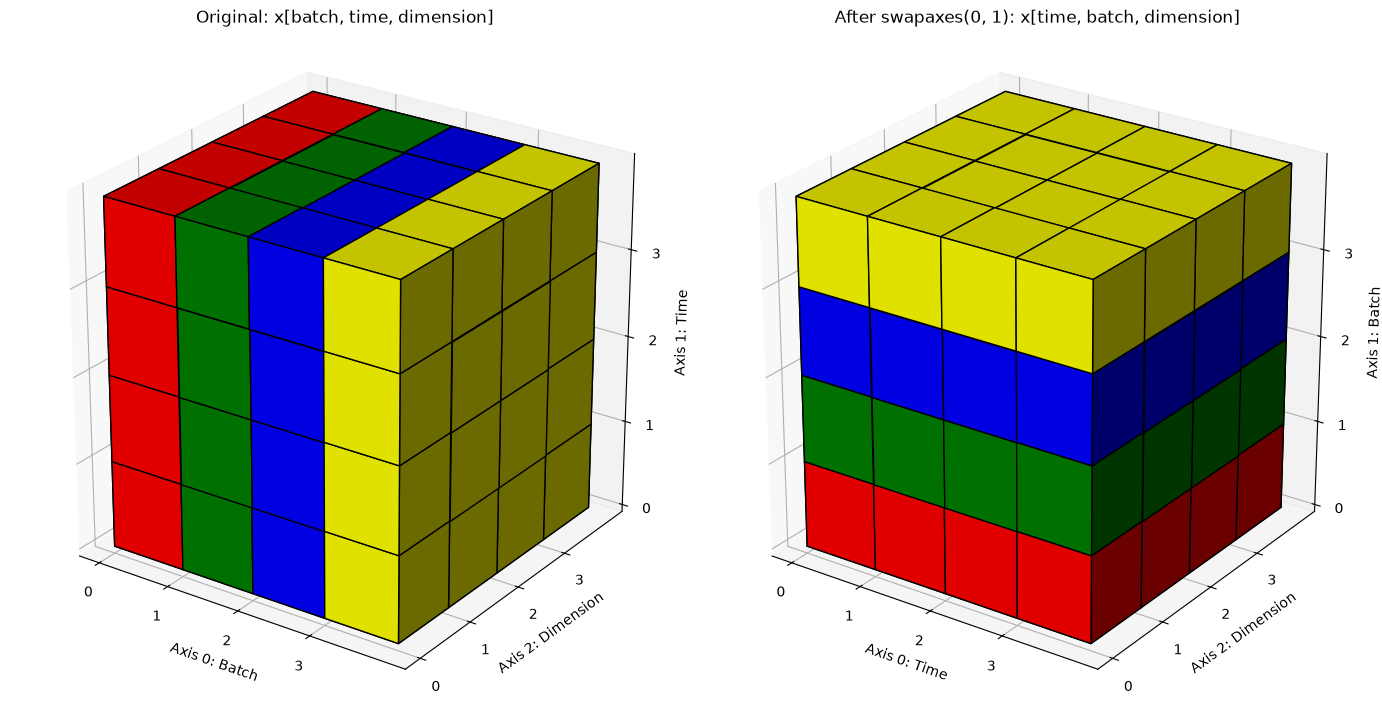

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

N = 4

# Original: x[batch, time, dimension]
x = np.zeros((N, N, N), dtype=int)

# Color depends on batch
for b in range(N):
    x[b, :, :] = b

# Swap axes 0 and 1
# Now: x_swapped[time, batch, dimension]
x_swapped = np.swapaxes(x, 0, 1)

colors = ["red", "green", "blue", "yellow"]
cmap = ListedColormap(colors)

def plot_tensor_cube(ax, data, title, axis_labels):
    """
    Matplotlib voxels expects data as:
    data[x_axis, y_axis, z_axis]

    We want:
    x-axis = tensor axis 0
    y-axis = tensor axis 2
    z-axis = tensor axis 1  <-- vertical bottom-to-top
    """
    data_for_plot = np.transpose(data, (0, 2, 1))

    filled = np.ones_like(data_for_plot, dtype=bool)
    facecolors = cmap(data_for_plot / (N - 1))

    ax.voxels(
        filled,
        facecolors=facecolors,
        edgecolor="black"
    )

    ax.set_title(title)
    ax.set_xlabel(axis_labels[0])
    ax.set_ylabel(axis_labels[2])
    ax.set_zlabel(axis_labels[1])

    ax.set_xticks(range(N))
    ax.set_yticks(range(N))
    ax.set_zticks(range(N))

    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=25, azim=-55)

fig = plt.figure(figsize=(14, 7))

ax1 = fig.add_subplot(121, projection="3d")
plot_tensor_cube(
    ax1,
    x,
    "Original: x[batch, time, dimension]",
    ["Axis 0: Batch", "Axis 1: Time", "Axis 2: Dimension"]
)

ax2 = fig.add_subplot(122, projection="3d")
plot_tensor_cube(
    ax2,
    x_swapped,
    "After swapaxes(0, 1): x[time, batch, dimension]",
    ["Axis 0: Time", "Axis 1: Batch", "Axis 2: Dimension"]
)

plt.tight_layout()
plt.show()

In [13]:
import numpy as np

# Shape: (batch, time, dimension)
b = np.array([
    [
        ['a11', 'a12', 'a13', 'a14'],
        ['a21', 'a22', 'a23', 'a24'],
        ['a31', 'a32', 'a33', 'a34'],
        ['a41', 'a42', 'a43', 'a44'],
    ],
    [
        ['b11', 'b12', 'b13', 'b14'],
        ['b21', 'b22', 'b23', 'b24'],
        ['b31', 'b32', 'b33', 'b34'],
        ['b41', 'b42', 'b43', 'b44'],
    ],
    [
        ['c11', 'c12', 'c13', 'c14'],
        ['c21', 'c22', 'c23', 'c24'],
        ['c31', 'c32', 'c33', 'c34'],
        ['c41', 'c42', 'c43', 'c44'],
    ],
    [
        ['d11', 'd12', 'd13', 'd14'],
        ['d21', 'd22', 'd23', 'd24'],
        ['d31', 'd32', 'd33', 'd34'],
        ['d41', 'd42', 'd43', 'd44'],
    ],
])

print("Original shape:", b.shape)
print("\nOriginal array:")
print(b)

# Deep copy (for numeric/string arrays, copy() is sufficient)
c = b.copy()

# Swap batch and time axes
d = np.swapaxes(c, 0, 1)

print("\nSwapped shape:", d.shape)
print("\nArray after swapping axes 0 and 1:")
print(d)

# ------------------------------------------------------------------
# Verify how indices moved
# swapaxes(0, 1) means:
#     d[i, j, k] = b[j, i, k]
# ------------------------------------------------------------------

print("\nVerification:")
print(f"b[0, 1] = {b[0, 1]}")
print(f"d[1, 0] = {d[1, 0]}")

assert np.array_equal(b[0, 1], d[1, 0])
assert np.array_equal(b[2, 3], d[3, 2])
assert np.array_equal(b[1, 2], d[2, 1])

print("\nAll assertions passed!")

# Example element mapping
print("\nExample element movement:")
print("Original :", b[2, 1, 3])   # c24
print("Swapped  :", d[1, 2, 3])   # c24

Original shape: (4, 4, 4)

Original array:
[[['a11' 'a12' 'a13' 'a14']
  ['a21' 'a22' 'a23' 'a24']
  ['a31' 'a32' 'a33' 'a34']
  ['a41' 'a42' 'a43' 'a44']]

 [['b11' 'b12' 'b13' 'b14']
  ['b21' 'b22' 'b23' 'b24']
  ['b31' 'b32' 'b33' 'b34']
  ['b41' 'b42' 'b43' 'b44']]

 [['c11' 'c12' 'c13' 'c14']
  ['c21' 'c22' 'c23' 'c24']
  ['c31' 'c32' 'c33' 'c34']
  ['c41' 'c42' 'c43' 'c44']]

 [['d11' 'd12' 'd13' 'd14']
  ['d21' 'd22' 'd23' 'd24']
  ['d31' 'd32' 'd33' 'd34']
  ['d41' 'd42' 'd43' 'd44']]]

Swapped shape: (4, 4, 4)

Array after swapping axes 0 and 1:
[[['a11' 'a12' 'a13' 'a14']
  ['b11' 'b12' 'b13' 'b14']
  ['c11' 'c12' 'c13' 'c14']
  ['d11' 'd12' 'd13' 'd14']]

 [['a21' 'a22' 'a23' 'a24']
  ['b21' 'b22' 'b23' 'b24']
  ['c21' 'c22' 'c23' 'c24']
  ['d21' 'd22' 'd23' 'd24']]

 [['a31' 'a32' 'a33' 'a34']
  ['b31' 'b32' 'b33' 'b34']
  ['c31' 'c32' 'c33' 'c34']
  ['d31' 'd32' 'd33' 'd34']]

 [['a41' 'a42' 'a43' 'a44']
  ['b41' 'b42' 'b43' 'b44']
  ['c41' 'c42' 'c43' 'c44']
  ['d41' 'd42